In [6]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Baseline models
from sklearn.svm import SVC, LinearSVC
from sklearn.dummy        import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree         import DecisionTreeClassifier
from sklearn.neighbors    import KNeighborsClassifier
from sklearn.naive_bayes  import GaussianNB
from sklearn.ensemble     import RandomForestClassifier, GradientBoostingClassifier
from xgboost              import XGBClassifier

## 1. Label Map

In [7]:
LABEL_MAP = {
    0: "Drought",
    1: "Earthquake",
    2: "Epidemic",
    3: "Extreme Temp",
    4: "Flood",
    5: "Landslide",
    6: "Storm",
    7: "Wildfire",
}
TARGET_NAMES = [LABEL_MAP[i] for i in sorted(LABEL_MAP)]

## 2. Load CLeaned

In [8]:
data = pd.read_excel('../data/processed/cleaned_disaster_dataset.xlsx')
data.head()

,event_duration_log_norm,magnitude_missing,subregion_Australia and New Zealand,subregion_Central Asia,subregion_Eastern Asia,subregion_Eastern Europe,subregion_Latin America and the Caribbean,subregion_Melanesia,subregion_Micronesia,subregion_Northern Africa,...,magnitude_scale_Km2,magnitude_scale_Kph,magnitude_scale_Moment Magnitude,magnitude_scale_Morbidity rate,magnitude_scale_Vaccinated,magnitude_scale_°C,total_deaths_normalized,total_damage_normalized,magnitude_scaled,disaster_type_encoded
0,0.0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,3.041543,1.269683,1.151770,6
1,0.0,1,0,0,0,0,1,0,0,0,...,1,0,0,0,0,0,1.616439,-0.664108,-0.520597,4
2,0.0,1,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0.533946,-0.664108,-0.520597,2
3,0.0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,1.255302,-0.664108,0.077794,1
4,0.0,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,5.584036,-0.664108,-0.520597,0


## 3. Define X Y

In [9]:
X = data.drop("disaster_type_encoded", axis=1)
y = data["disaster_type_encoded"]

for code, name in LABEL_MAP.items():
    n = (y == code).sum()
    print(f"  {code} {name:<20} {n:>5}  ({n/len(y)*100:.1f}%)")

  0 Drought                803  (4.6%)
  1 Earthquake            1651  (9.4%)
  2 Epidemic              1622  (9.3%)
  3 Extreme Temp           730  (4.2%)
  4 Flood                 6183  (35.4%)
  5 Landslide              918  (5.3%)
  6 Storm                 5053  (28.9%)
  7 Wildfire               514  (2.9%)


## 4. Split Train 80/20 Test
`stratify=y` ensures every class lands at the same proportion in both splits. 

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

# Verify stratification held
print("\nClass proportions — train vs test (should match):")
for code, name in LABEL_MAP.items():
    tr = (y_train == code).sum() / len(y_train) * 100
    te = (y_test == code).sum() / len(y_test) * 100
    print(f"  {name:<20}  train {tr:.1f}%   test {te:.1f}%")

Train size: (12231, 33)
Test size: (5243, 33)

Class proportions — train vs test (should match):
  Drought               train 4.6%   test 4.6%
  Earthquake            train 9.5%   test 9.4%
  Epidemic              train 9.3%   test 9.3%
  Extreme Temp          train 4.2%   test 4.2%
  Flood                 train 35.4%   test 35.4%
  Landslide             train 5.2%   test 5.3%
  Storm                 train 28.9%   test 28.9%
  Wildfire              train 2.9%   test 2.9%


## 5. Cross-Validation Setup

`StratifiedKFold` preserves class proportions in every fold — essential with a 12× imbalance.  
CV is run **on the training set only**; the test set remains unseen.

In [12]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING = ["accuracy", "f1_macro", "f1_weighted"]

## 8. Model

9 models from simplest to most powerful:

| Model | Type | Notes |
|-------|------|-------|
|SVC (RBF) | Radial Basis Function | Best at non-linear boundaries; slower on large data |
| SVC (Linear) | Linear | Similar to Logistic Regression but via margin maximisation |
| LinearSVC| Linear (liblinear) | Much faster than `SVC(kernel='linear')`, uses a different solver
| Dummy | Sanity check | Always predicts most frequent class |
| Logistic Regression | Linear | Fast, interpretable |
| Naive Bayes | Probabilistic | Good for sparse features |
| Decision Tree | Non-linear | Single tree, prone to overfit |
| Random Forest | Ensemble (bagging) | Strong baseline |
| XGBoost | Ensemble (boosting) | Usually top performer |
<!-- | LightGBM | Ensemble (boosting) | Faster than XGBoost on large data | -->

All non-dummy models use `class_weight='balanced'` to handle the 12× imbalance.

In [13]:
models = {
    "Dummy"              : DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(
                               max_iter=1000,
                               class_weight="balanced",
                               random_state=42),
    "Naive Bayes"        : GaussianNB(),
    "Decision Tree"      : DecisionTreeClassifier(
                               class_weight="balanced",
                               random_state=42),
    "Random Forest"      : RandomForestClassifier(
                               n_estimators=200,
                               class_weight="balanced",
                               random_state=42,
                               n_jobs=-1),
    "XGBoost"            : XGBClassifier(
                               n_estimators=200,
                               eval_metric="mlogloss",
                               random_state=42,
                               n_jobs=-1,
                               verbosity=0),
#     "LightGBM"           : LGBMClassifier(
#                                n_estimators=200,
#                                class_weight="balanced",
#                                random_state=42,
#                                n_jobs=-1,
#                                verbose=-1),
    "SVM (RBF)"          : SVC(
                               kernel="rbf",
                               class_weight="balanced",
                               random_state=42,
                               cache_size=500),
    "LinearSVC"          : LinearSVC(
                               class_weight="balanced",
                               random_state=42,
                               max_iter=2000),
}

## 9. Cross-Validation Results (Train Set Only)

> **Why F1-Macro?**  
> Accuracy is misleading here — a model that always predicts Flood scores 35%.  
> F1-Macro averages the F1 score across all 8 classes equally, penalising 
> the model for ignoring rare classes like Wildfire (2.9%).

In [14]:
cv_summary = []

for name, model in models.items():
    scores = cross_validate(
        model, X_train, y_train,
        cv=cv, scoring=SCORING,
        return_train_score=False, n_jobs=-1
    )
    cv_summary.append({
        "Model"         : name,
        "Accuracy"      : scores["test_accuracy"].mean(),
        "Accuracy ±"    : scores["test_accuracy"].std(),
        "F1 Macro"      : scores["test_f1_macro"].mean(),
        "F1 Macro ±"    : scores["test_f1_macro"].std(),
        "F1 Weighted"   : scores["test_f1_weighted"].mean(),
        "F1 Weighted ±" : scores["test_f1_weighted"].std(),
    })
    print(f"{name:<22}  "
          f"Acc={scores['test_accuracy'].mean():.4f}±{scores['test_accuracy'].std():.4f}  "
          f"F1-Mac={scores['test_f1_macro'].mean():.4f}±{scores['test_f1_macro'].std():.4f}  "
          f"F1-Wtd={scores['test_f1_weighted'].mean():.4f}±{scores['test_f1_weighted'].std():.4f}")

cv_df = pd.DataFrame(cv_summary).set_index("Model")

Dummy                   Acc=0.3539±0.0002  F1-Mac=0.0653±0.0000  F1-Wtd=0.1850±0.0002


/Users/yazu/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/yazu/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/yazu/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/yazu/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/yazu/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:336: 

Logistic Regression     Acc=0.7634±0.0043  F1-Mac=0.7281±0.0051  F1-Wtd=0.7784±0.0039
Naive Bayes             Acc=0.6853±0.0100  F1-Mac=0.6768±0.0089  F1-Wtd=0.6992±0.0138
Decision Tree           Acc=0.8499±0.0045  F1-Mac=0.7672±0.0048  F1-Wtd=0.8581±0.0041
Random Forest           Acc=0.8710±0.0054  F1-Mac=0.7792±0.0063  F1-Wtd=0.8733±0.0048
XGBoost                 Acc=0.8993±0.0051  F1-Mac=0.7963±0.0096  F1-Wtd=0.8916±0.0050
SVM (RBF)               Acc=0.7854±0.0048  F1-Mac=0.7490±0.0039  F1-Wtd=0.7986±0.0053
LinearSVC               Acc=0.8540±0.0085  F1-Mac=0.7699±0.0107  F1-Wtd=0.8600±0.0075


/Users/yazu/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yazu/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yazu/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yazu/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yazu/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yazu/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yazu/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWar

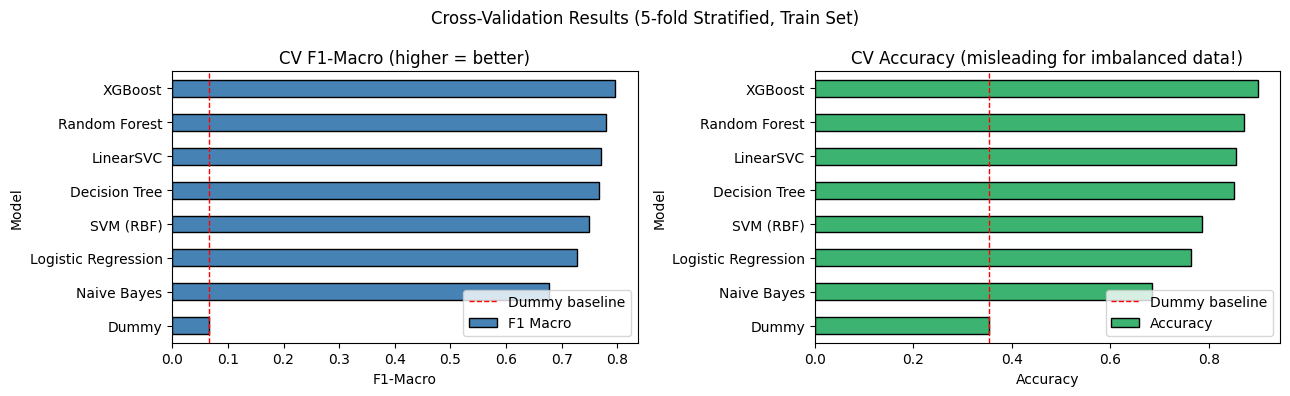

In [15]:
# Visual comparison — CV F1-Macro vs Accuracy
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cv_df["F1 Macro"].sort_values().plot(
    kind="barh", ax=axes[0], color="steelblue", edgecolor="black"
)
axes[0].set_title("CV F1-Macro (higher = better)")
axes[0].set_xlabel("F1-Macro")
axes[0].axvline(cv_df.loc["Dummy", "F1 Macro"], color="red",
                linestyle="--", linewidth=1, label="Dummy baseline")
axes[0].legend()

cv_df["Accuracy"].sort_values().plot(
    kind="barh", ax=axes[1], color="mediumseagreen", edgecolor="black"
)
axes[1].set_title("CV Accuracy (misleading for imbalanced data!)")
axes[1].set_xlabel("Accuracy")
axes[1].axvline(cv_df.loc["Dummy", "Accuracy"], color="red",
                linestyle="--", linewidth=1, label="Dummy baseline")
axes[1].legend()

plt.suptitle("Cross-Validation Results (5-fold Stratified, Train Set)", fontsize=12)
plt.tight_layout()
plt.show()

## 10. Test Set Evaluation (Held-Out 20%)

Each model is refit on the full training set, then evaluated once on the test set.

In [16]:
test_summary = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    test_summary.append({
        "Model"      : name,
        "Accuracy"   : accuracy_score(y_test, y_pred),
        "F1 Macro"   : f1_score(y_test, y_pred, average="macro"),
        "F1 Weighted": f1_score(y_test, y_pred, average="weighted"),
    })

test_df = pd.DataFrame(test_summary).set_index("Model")
test_df.sort_values("F1 Macro", ascending=False).round(4)

,Accuracy,F1 Macro,F1 Weighted
Model,,,
XGBoost,0.9044,0.8024,0.8972
Random Forest,0.8669,0.7795,0.8708
Decision Tree,0.8442,0.7685,0.8538
LinearSVC,0.8545,0.7663,0.8595
SVM (RBF),0.7931,0.7556,0.8063
Logistic Regression,0.7595,0.7250,0.7742
Naive Bayes,0.6889,0.6793,0.7036
Dummy,0.3538,0.0653,0.1849


In [17]:
# Per-class classification report for every model
for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, target_names=TARGET_NAMES))

  Dummy
              precision    recall  f1-score   support

     Drought       0.00      0.00      0.00       241
  Earthquake       0.00      0.00      0.00       495
    Epidemic       0.00      0.00      0.00       487
Extreme Temp       0.00      0.00      0.00       219
       Flood       0.35      1.00      0.52      1855
   Landslide       0.00      0.00      0.00       276
       Storm       0.00      0.00      0.00      1516
    Wildfire       0.00      0.00      0.00       154

    accuracy                           0.35      5243
   macro avg       0.04      0.12      0.07      5243
weighted avg       0.13      0.35      0.18      5243

  Logistic Regression
              precision    recall  f1-score   support

     Drought       0.31      0.68      0.42       241
  Earthquake       1.00      1.00      1.00       495
    Epidemic       1.00      1.00      1.00       487
Extreme Temp       1.00      1.00      1.00       219
       Flood       0.92      0.41      0.57     

## 11. Confusion Matrices

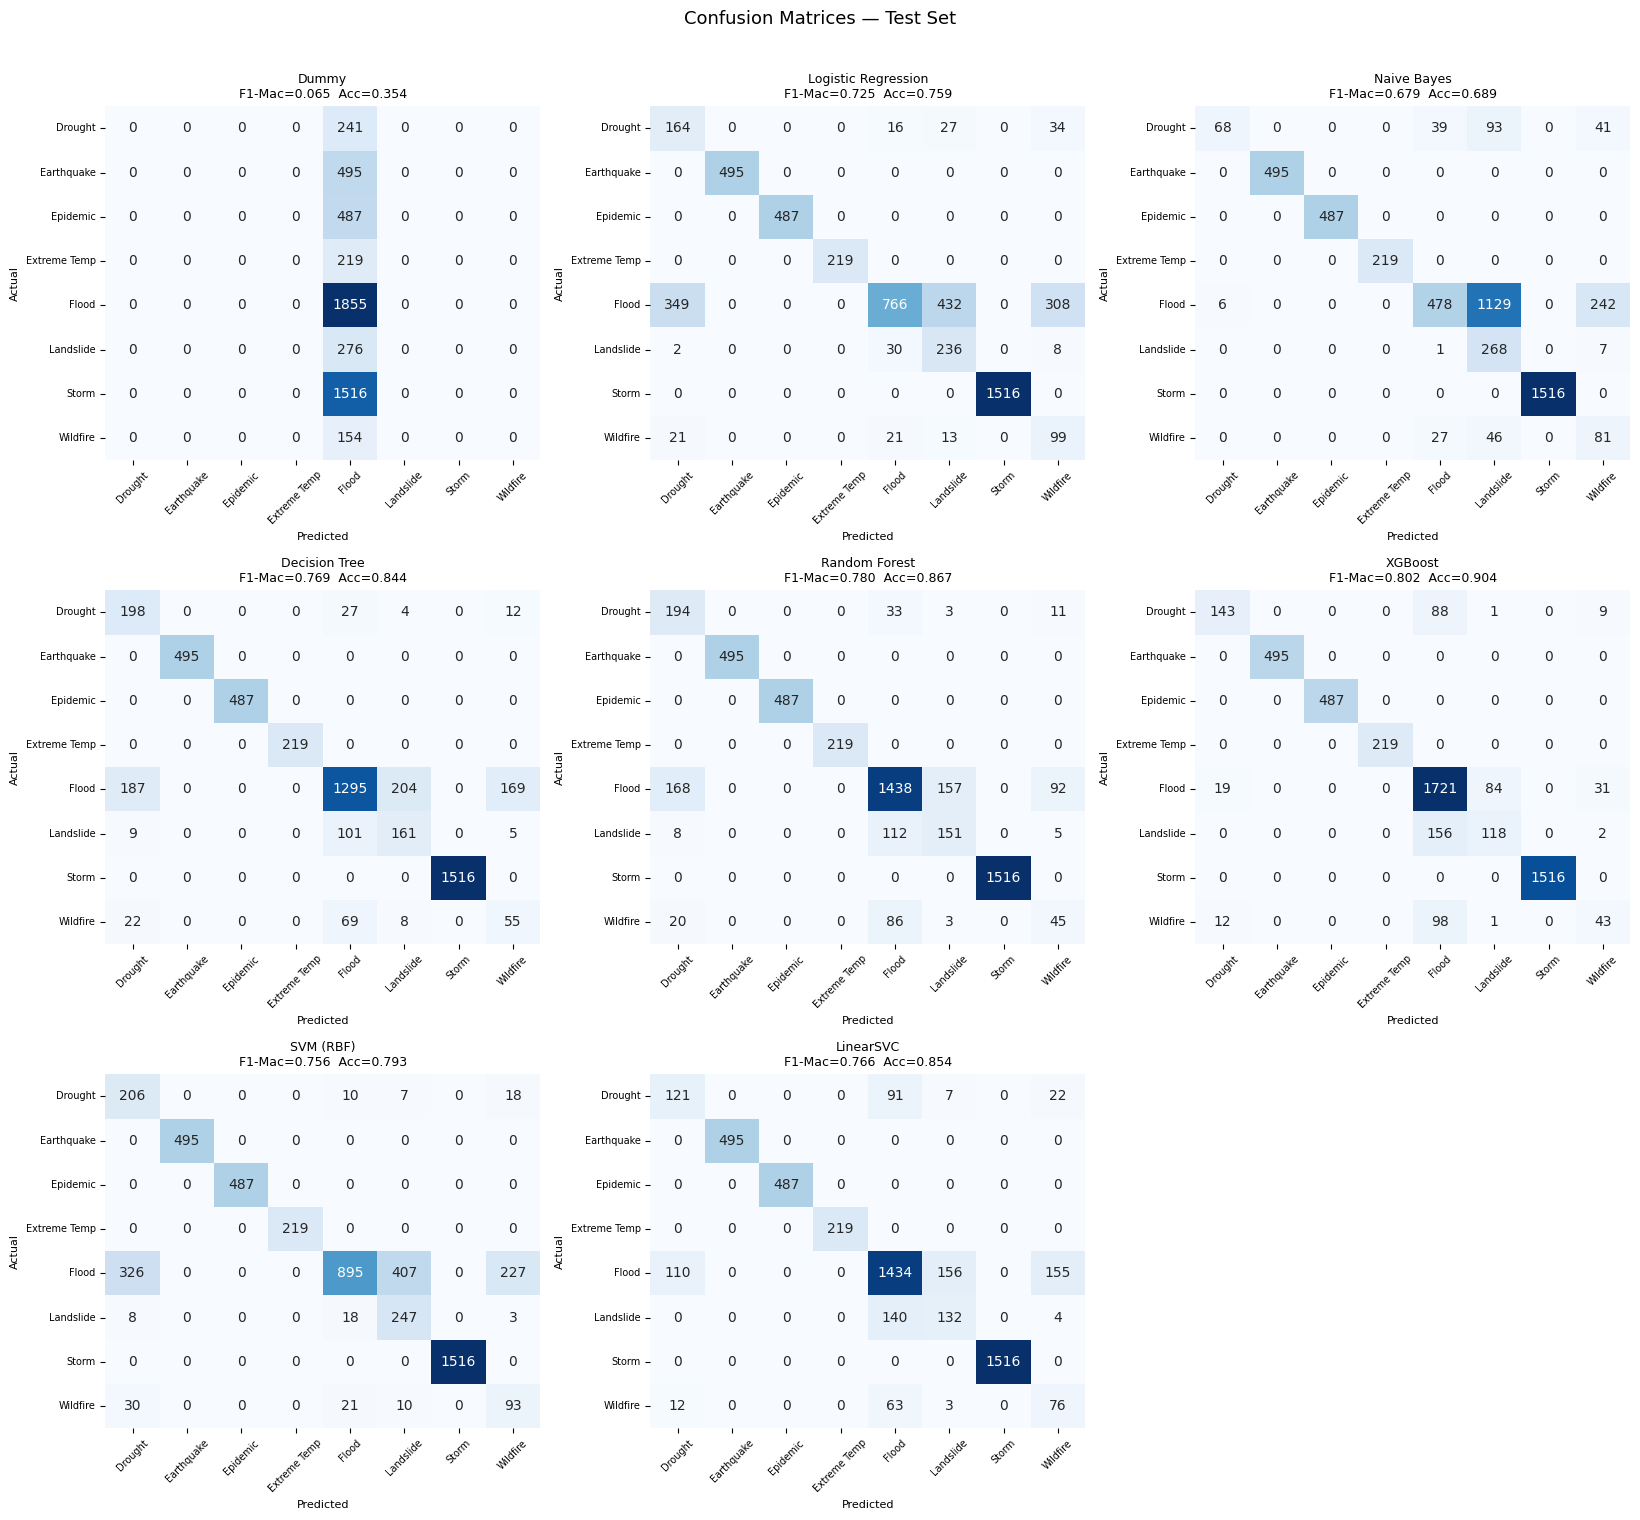

In [18]:
n_models = len(models)              # 9 models → 3×3 grid
ncols    = 3
nrows    = (n_models + ncols - 1) // ncols   # auto-compute rows

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5.5, nrows * 5))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", ax=ax,
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES,
                cmap="Blues", cbar=False)
    f1  = f1_score(y_test, y_pred, average="macro")
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f"{name}\nF1-Mac={f1:.3f}  Acc={acc:.3f}", fontsize=9)
    ax.set_xlabel("Predicted", fontsize=8)
    ax.set_ylabel("Actual", fontsize=8)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.tick_params(axis="y", rotation=0,  labelsize=7)

# Hide unused subplots
for ax in axes[n_models:]:
    ax.set_visible(False)

plt.suptitle("Confusion Matrices — Test Set", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 12. Feature Importance (Tree-Based Models)

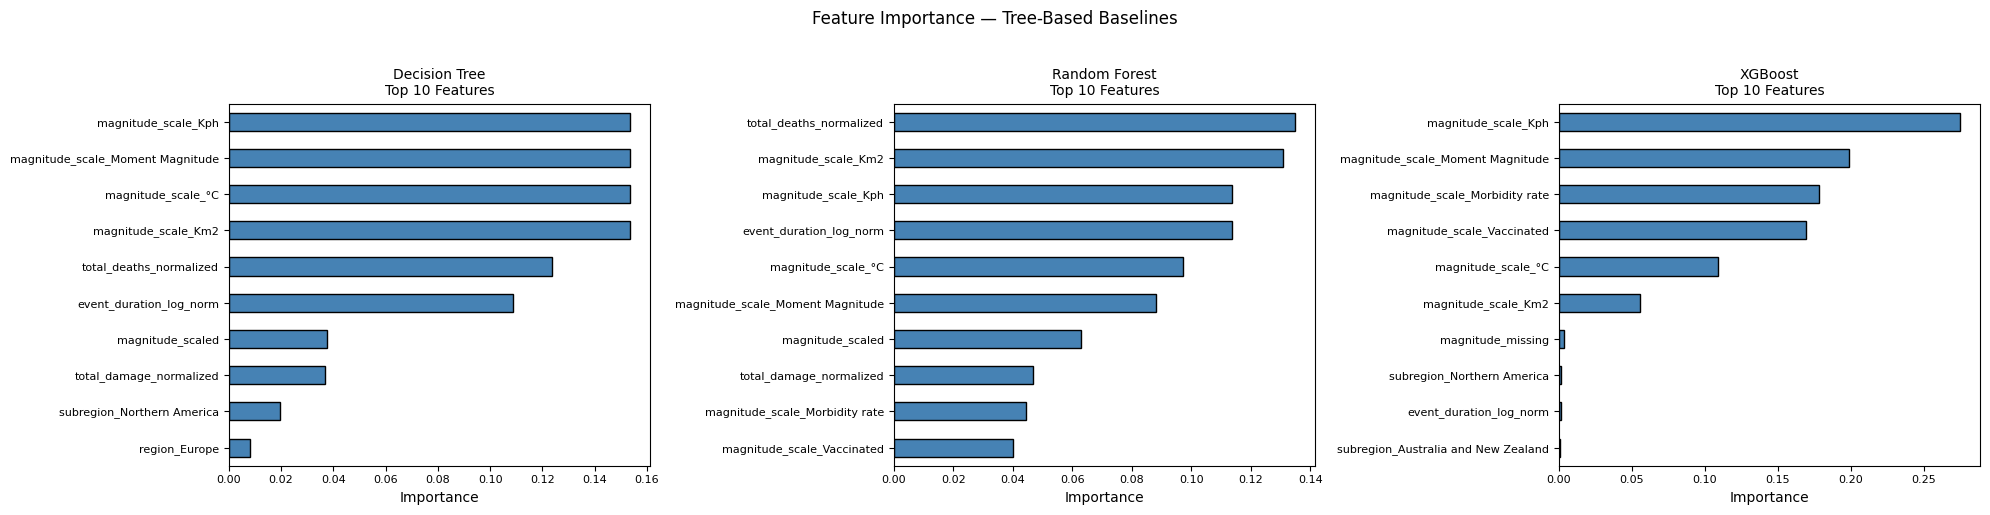

In [19]:
tree_models = {
    "Decision Tree": models["Decision Tree"],
    "Random Forest": models["Random Forest"],
    "XGBoost"      : models["XGBoost"],
}

fig, axes = plt.subplots(1, len(tree_models), figsize=(20, 5))

for ax, (name, model) in zip(axes, tree_models.items()):
    imp = pd.Series(model.feature_importances_, index=X.columns)
    imp.nlargest(10).sort_values().plot(
        kind="barh", ax=ax, color="steelblue", edgecolor="black"
    )
    ax.set_title(f"{name}\nTop 10 Features", fontsize=10)
    ax.set_xlabel("Importance")
    ax.tick_params(labelsize=8)

plt.suptitle("Feature Importance — Tree-Based Baselines", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 13. Comparison 

In [20]:
print("CV vs Test F1-Macro comparison:")
print(f"{'Model':<22}  {'CV F1-Mac':>10}  {'Test F1-Mac':>11}")
print("-" * 48)
for name in models:
    cv_f1  = cv_df.loc[name, "F1 Macro"]
    tst_f1 = test_df.loc[name, "F1 Macro"]
    gap    = tst_f1 - cv_f1
    flag   = "  ⚠ overfit" if gap < -0.05 else ""
    print(f"{name:<22}  {cv_f1:>10.4f}  {tst_f1:>11.4f}{flag}")

print("\nBest model by Test F1-Macro:")
best = test_df["F1 Macro"].idxmax()
print(f"  → {best}  (F1-Macro = {test_df.loc[best, 'F1 Macro']:.4f})")

print("""
Next steps:
  1. Investigate Wildfire & Drought — lowest per-class F1 across all models
  2. Consider removing total_deaths / total_damage if this is a pre-event predictor
  3. Hyperparameter tuning on the best 1-2 models (GridSearchCV / Optuna)
  4. Try SMOTE oversampling on minority classes if F1-Macro on rare classes stays low
""")

CV vs Test F1-Macro comparison:
Model                    CV F1-Mac  Test F1-Mac
------------------------------------------------
Dummy                       0.0653       0.0653
Logistic Regression         0.7281       0.7250
Naive Bayes                 0.6768       0.6793
Decision Tree               0.7672       0.7685
Random Forest               0.7792       0.7795
XGBoost                     0.7963       0.8024
SVM (RBF)                   0.7490       0.7556
LinearSVC                   0.7699       0.7663

Best model by Test F1-Macro:
  → XGBoost  (F1-Macro = 0.8024)

Next steps:
  1. Investigate Wildfire & Drought — lowest per-class F1 across all models
  2. Consider removing total_deaths / total_damage if this is a pre-event predictor
  3. Hyperparameter tuning on the best 1-2 models (GridSearchCV / Optuna)
  4. Try SMOTE oversampling on minority classes if F1-Macro on rare classes stays low

